In [12]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

I0000 00:00:1787674097.177463   21897 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787674098.541042   21897 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787674103.918679   21897 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
baseline_metrics = pd.read_csv(
    "../results/metrics/baseline_model_metrics.csv",
    index_col=0
)

baseline_metrics

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,ANN,0.8744,0.8765,0.8728,0.8746,0.9484
1,RNN,0.4977,0.4998,0.9095,0.6451,0.5000
2,LSTM,0.8653,0.8796,0.8476,0.8633,0.9321
3,GRU,0.8721,0.8690,0.8776,0.8733,0.9353
4,Bi-LSTM,0.8643,0.8661,0.8631,0.8646,0.9358


In [3]:
baseline_predictions = pd.read_csv(
    "../results/metrics/baseline_predictions.csv"
)

baseline_predictions.head()

,Actual,ANN_Probability,ANN_Prediction,RNN_Probability,RNN_Prediction,LSTM_Probability,LSTM_Prediction,GRU_Probability,GRU_Prediction,BiLSTM_Probability,BiLSTM_Prediction
0,1,0.000014,0,0.555182,1,0.961735,1,0.999866,1,0.195447,0
1,0,0.996182,1,0.555051,1,0.003182,0,0.008233,0,0.001881,0
2,0,0.950208,1,0.413207,0,0.000153,0,0.992599,1,0.163316,0
3,0,0.983201,1,0.555540,1,0.947657,1,0.998238,1,0.912420,1
4,1,0.000008,0,0.555340,1,0.995422,1,0.041831,0,0.999731,1


In [4]:
class_names = [
    "Negative",
    "Positive"
]   

y_test = baseline_predictions["Actual"].values

bi_lstm_pred = (
    baseline_predictions["BiLSTM_Prediction"].values
)

print(
    classification_report(
        y_test,
        bi_lstm_pred,
        target_names=class_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative       0.49      0.52      0.50      3705
    Positive       0.49      0.45      0.47      3733

    accuracy                           0.49      7438
   macro avg       0.49      0.49      0.49      7438
weighted avg       0.49      0.49      0.49      7438



In [5]:
def calculate_metrics(y_true, y_pred, y_prob):
    
    metrics = {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        
        "F1 Score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        
        "ROC-AUC": roc_auc_score(
            y_true,
            y_prob
        )
    }
    
    return metrics

In [6]:
model_predictions = {
    "ANN": (
        baseline_predictions["ANN_Prediction"].values,
        baseline_predictions["ANN_Probability"].values
    ),
    
    "RNN": (
        baseline_predictions["RNN_Prediction"].values,
        baseline_predictions["RNN_Probability"].values
    ),
    
    "LSTM": (
        baseline_predictions["LSTM_Prediction"].values,
        baseline_predictions["LSTM_Probability"].values
    ),
    
    "GRU": (
        baseline_predictions["GRU_Prediction"].values,
        baseline_predictions["GRU_Probability"].values
    ),
    
    "Bi-LSTM": (
        baseline_predictions["BiLSTM_Prediction"].values,
        baseline_predictions["BiLSTM_Probability"].values
    )
}

In [7]:
evaluation_results = []

for model_name, (predictions, probabilities) in model_predictions.items():
    
    metrics = calculate_metrics(
        y_test,
        predictions,
        probabilities
    )
    
    metrics["Model"] = model_name
    
    evaluation_results.append(metrics)

In [8]:
evaluation_df = pd.DataFrame(
    evaluation_results
)

evaluation_df = evaluation_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
]

evaluation_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,ANN,0.518553,0.522961,0.463702,0.491552,0.527011
1,RNN,0.497849,0.499852,0.903831,0.643709,0.503211
2,LSTM,0.490858,0.491843,0.436110,0.462303,0.490747
3,GRU,0.482522,0.484213,0.476560,0.480356,0.469585
4,Bi-LSTM,0.486421,0.487402,0.450844,0.468411,0.489201


In [14]:
optimized_history = tf.keras.models.load_model("../models/ann/ann_baseline_5_90.keras")

optimized_history.history

E0000 00:00:1787674128.545718   21897 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


AttributeError: 'Sequential' object has no attribute 'history'

In [20]:
import pickle

# Open the file in binary read mode ('rb')
with open('../models/ann/ann_history_5_90.pkl', 'rb') as file:
    optimized_history = pickle.load(file)

# Now 'loaded_data' contains your original Python object
print(optimized_history)

{'accuracy': [0.6186716556549072, 0.7912692427635193, 0.8463621735572815, 0.8751477003097534, 0.8909379243850708, 0.9023195505142212, 0.912980854511261, 0.9191182851791382, 0.9236709475517273, 0.9289151430130005], 'loss': [0.6802647709846497, 0.6015236973762512, 0.4717157781124115, 0.36164590716362, 0.30069130659103394, 0.26747822761535645, 0.24028471112251282, 0.22468367218971252, 0.21008256077766418, 0.2009659856557846], 'val_accuracy': [0.7815566658973694, 0.869337260723114, 0.8868127465248108, 0.8950127959251404, 0.9003898501396179, 0.9041537642478943, 0.9049603343009949, 0.9067078828811646, 0.9076488614082336, 0.9076488614082336], 'val_loss': [0.6495821475982666, 0.5235453248023987, 0.38511282205581665, 0.30233967304229736, 0.26493656635284424, 0.24799305200576782, 0.2394985854625702, 0.23565450310707092, 0.23331831395626068, 0.23312027752399445]}


In [21]:
optimized_history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

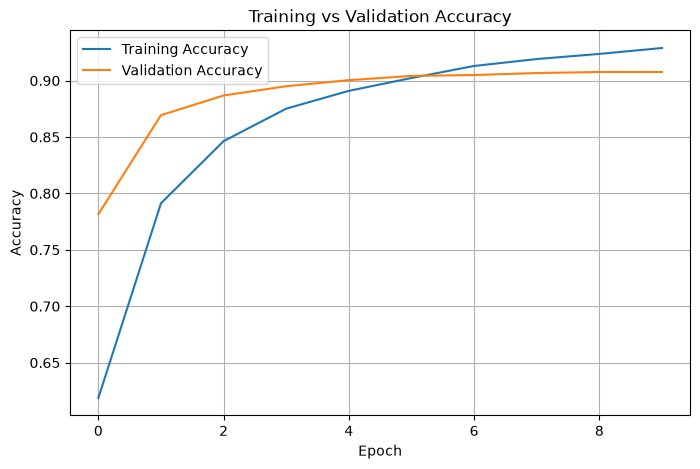

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    optimized_history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    optimized_history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

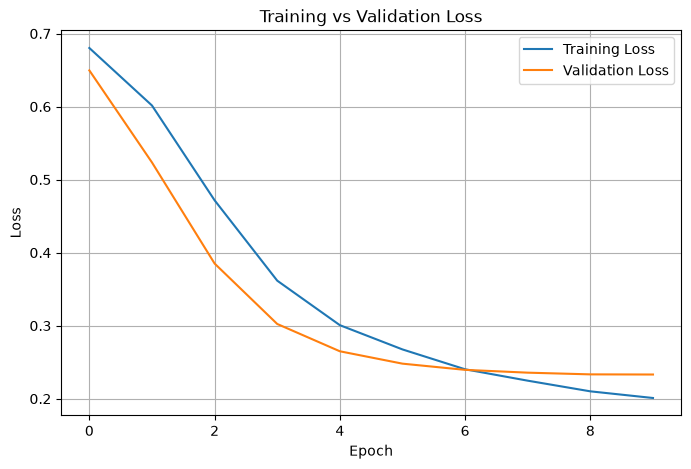

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    optimized_history["loss"],
    label="Training Loss"
)

plt.plot(
    optimized_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
optimized_predictions = (
    optimized_probabilities >= 0.5
).astype(int)